# Near-Duplicate Short Text Detection
## MinHash LSH vs Character N-gram Baseline

This notebook demonstrates two methods for detecting near-duplicate short text snippets.


In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])

# loguru is NOT pre-installed on Colab
_pip("loguru")

# Core packages (pre-installed on Colab, install locally to match Colab env)
if "google.colab" not in sys.modules:
    _pip("numpy==2.0.2", "matplotlib==3.10.0")

print("Dependencies installed successfully")



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


Dependencies installed successfully



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from loguru import logger
from pathlib import Path
import json, sys, numpy as np
from collections import Counter
from typing import List, Dict, Tuple, Set
import hashlib
import matplotlib.pyplot as plt
logger.remove()
logger.add(sys.stdout, level='INFO', format='{time:HH:mm:ss}|{level:<7}|{message}')
print('Imports OK')

Imports OK


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-c84097-reading-vector-patterns-rvp-a-cognitive/main/round-1/experiment-1/demo/mini_demo_data.json"
import json, os
def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as r: return json.loads(r.read().decode())
    except: pass
    if os.path.exists('mini_demo_data.json'):
        with open('mini_demo_data.json') as f: return json.load(f)
    raise FileNotFoundError('Could not load mini_demo_data.json')
print('load_data defined')

load_data defined


In [4]:
data = load_data()
print(f"Loaded: {data['metadata']['num_pairs']} pairs")


Loaded: 20 pairs


## Configuration
All tunable parameters below. Start minimal.


In [5]:
NUM_TRIALS = 1
NUM_PAIRS = 20
NUM_HASHES = 32
NUM_BANDS = 8
ROWS_PER_BAND = NUM_HASHES // NUM_BANDS
BASELINE_THRESHOLD = 0.5
MINHASH_THRESHOLD = 0.1
N_GRAM = 3
K_SHINGLE = 2
TUNE_THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5]
print('Config set')

Config set


## 1. MinHash Implementation
MinHash estimates Jaccard similarity efficiently.


In [6]:
class MinHash:
    def __init__(self, num_hashes=128, seed=42):
        self.num_hashes = num_hashes
        self.hash_funcs = []
        np.random.seed(seed)
        self.prime = 2**31 - 1
        for i in range(num_hashes):
            a = np.random.randint(1, self.prime)
            b = np.random.randint(0, self.prime)
            self.hash_funcs.append((a, b))
    def compute_signature(self, shingles):
        signature = np.full(self.num_hashes, self.prime, dtype=np.int64)
        for shingle in shingles:
            h = int(hashlib.md5(shingle.encode()).hexdigest(), 16) % self.prime
            for i, (a, b) in enumerate(self.hash_funcs):
                v = (a * h + b) % self.prime
                if v < signature[i]: signature[i] = v
        return signature
print('MinHash defined')

MinHash defined


## 2. Locality-Sensitive Hashing
LSH groups similar items for sub-linear query.


In [7]:
class MinHashLSH:
    def __init__(self, num_hashes=128, num_bands=32, rows_per_band=4):
        self.num_hashes = num_hashes
        self.num_bands = num_bands
        self.rows_per_band = rows_per_band
        assert num_hashes == num_bands * rows_per_band
        self.tables = [{} for _ in range(num_bands)]
    def index(self, doc_id, signature):
        for i in range(self.num_bands):
            start = i * self.rows_per_band
            end = start + self.rows_per_band
            band = tuple(signature[start:end])
            bh = hash(band)
            if bh not in self.tables[i]: self.tables[i][bh] = []
            self.tables[i][bh].append(doc_id)
    def query(self, signature):
        candidates = set()
        for i in range(self.num_bands):
            start = i * self.rows_per_band
            end = start + self.rows_per_band
            band = tuple(signature[start:end])
            bh = hash(band)
            if bh in self.tables[i]: candidates.update(self.tables[i][bh])
        return candidates
print('MinHashLSH defined')

MinHashLSH defined


## 3. Helper Functions
Text to shingles conversion.


In [8]:
def get_char_ngrams(text, n=3):
    text = text.lower().strip()
    if len(text) < n: return {text}
    return {text[i:i+n] for i in range(len(text) - n + 1)}
def get_word_shingles(text, k=2):
    words = text.lower().strip().split()
    if len(words) < k: return {text.lower().strip()}
    return {' '.join(words[i:i+k]) for i in range(len(words) - k + 1)}
def jaccard_similarity(s1, s2):
    if not s1 or not s2: return 0.0
    return len(s1 & s2) / len(s1 | s2) if len(s1 | s2) > 0 else 0.0
def minhash_similarity(s1, s2):
    return np.mean(s1 == s2)
print('Helpers defined')

Helpers defined


## 4. Baseline Detector
Character n-gram similarity.


In [9]:
class BaselineNgramDetector:
    def __init__(self, n=3, threshold=0.5):
        self.n = n
        self.threshold = threshold
    def detect(self, t1, t2):
        return jaccard_similarity(get_char_ngrams(t1, self.n), get_char_ngrams(t2, self.n)) >= self.threshold
    def compute_similarity(self, t1, t2):
        return jaccard_similarity(get_char_ngrams(t1, self.n), get_char_ngrams(t2, self.n))
print('Baseline defined')

Baseline defined


## 5. MinHash LSH Detector
Proposed method with LSH indexing.


In [10]:
class MinHashDetector:
    def __init__(self, num_hashes=128, num_bands=32, threshold=0.5):
        self.num_hashes = num_hashes
        self.num_bands = num_bands
        self.rows_per_band = num_hashes // num_bands
        self.threshold = threshold
        self.minhash = MinHash(num_hashes)
        self.lsh = MinHashLSH(num_hashes, num_bands, self.rows_per_band)
        self.doc_signatures = {}
        self.doc_texts = {}
        self.next_doc_id = 0
    def _get_shingles(self, text):
        return get_word_shingles(text, k=K_SHINGLE)
    def index_text(self, text):
        doc_id = self.next_doc_id; self.next_doc_id += 1
        shingles = self._get_shingles(text)
        sig = self.minhash.compute_signature(shingles)
        self.lsh.index(doc_id, sig)
        self.doc_signatures[doc_id] = sig
        self.doc_texts[doc_id] = text
        return doc_id
    def detect(self, text):
        shingles = self._get_shingles(text)
        query_sig = self.minhash.compute_signature(shingles)
        candidates = self.lsh.query(query_sig)
        results = []
        for cid in candidates:
            if cid in self.doc_signatures:
                sim = minhash_similarity(query_sig, self.doc_signatures[cid])
                if sim >= self.threshold: results.append(cid)
        return results
    def compute_similarity(self, t1, t2):
        s1 = self.minhash.compute_signature(self._get_shingles(t1))
        s2 = self.minhash.compute_signature(self._get_shingles(t2))
        return minhash_similarity(s1, s2)
print('MinHashDetector defined')

MinHashDetector defined


## 6. Dataset Generation
Generate synthetic text pairs.


In [11]:
def generate_test_dataset(num_pairs=500):
    base_texts = [
        'The quick brown fox jumps over the lazy dog',
        'Machine learning is a subset of artificial intelligence',
        'Python is a popular programming language for data science',
        'Climate change is a pressing global issue that requires action',
        'The stock market experienced significant volatility this quarter'
    ]
    test_pairs = []
    for i in range(num_pairs):
        base_idx = np.random.randint(0, len(base_texts))
        base_text = base_texts[base_idx]
        is_dup = np.random.random() < 0.7
        if is_dup:
            words = base_text.split()
            mod = np.random.choice(['substitute', 'delete', 'insert', 'reorder'])
            if mod == 'substitute' and len(words) > 3:
                words[np.random.randint(0, len(words))] = np.random.choice(['quickly', 'efficiently'])
            elif mod == 'delete' and len(words) > 5:
                words.pop(np.random.randint(0, len(words)))
            elif mod == 'insert' and len(words) > 2:
                words.insert(np.random.randint(0, len(words)), np.random.choice(['very', 'quite']))
            elif mod == 'reorder' and len(words) > 4:
                i1, i2 = np.random.choice(len(words), size=2, replace=False)
                words[i1], words[i2] = words[i2], words[i1]
            test_pairs.append({'text1': base_text, 'text2': ' '.join(words), 'is_duplicate': True, 'pair_id': i})
        else:
            other_idx = (base_idx + np.random.randint(1, len(base_texts))) % len(base_texts)
            test_pairs.append({'text1': base_text, 'text2': base_texts[other_idx], 'is_duplicate': False, 'pair_id': i})
    return test_pairs
print('generate_test_dataset defined')

generate_test_dataset defined


## 7. Evaluation
Compute precision, recall, F1.


In [12]:
def evaluate_detector(detector, test_pairs, detector_name, batch_mode=False):
    predictions = []
    true_labels = []
    if batch_mode and hasattr(detector, 'index_text'):
        for pair in test_pairs: detector.index_text(pair['text1'])
        for pair in test_pairs:
            similar = detector.detect(pair['text2'])
            is_detected = any(detector.doc_texts[cid] == pair['text1'] for cid in similar)
            predictions.append(is_detected)
            true_labels.append(pair['is_duplicate'])
    else:
        for pair in test_pairs:
            pred = detector.detect(pair['text1'], pair['text2'])
            predictions.append(pred)
            true_labels.append(pair['is_duplicate'])
    predictions = np.array(predictions)
    true_labels = np.array(true_labels)
    tp = np.sum((predictions == True) & (true_labels == True))
    fp = np.sum((predictions == True) & (true_labels == False))
    fn = np.sum((predictions == False) & (true_labels == True))
    tn = np.sum((predictions == False) & (true_labels == False))
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    acc = (tp + tn) / len(test_pairs)
    return {'detector_name': detector_name, 'precision': float(prec), 'recall': float(rec), 'f1_score': float(f1), 'accuracy': float(acc)}
print('evaluate_detector defined')

evaluate_detector defined


## 8. Threshold Tuning
Find optimal MinHash threshold.


In [13]:
def tune_minhash_threshold(test_pairs, thresholds=None):
    if thresholds is None: thresholds = TUNE_THRESHOLDS
    best_f1 = 0; best_thresh = 0.5
    for t in thresholds:
        d = MinHashDetector(num_hashes=NUM_HASHES, num_bands=NUM_BANDS, threshold=t)
        r = evaluate_detector(d, test_pairs, f'MinHash(t={t})', batch_mode=True)
        if r['f1_score'] > best_f1: best_f1 = r['f1_score']; best_thresh = t
    return {'best_threshold': best_thresh, 'best_f1': best_f1}
print('tune_minhash_threshold defined')

tune_minhash_threshold defined


## 9. Run Experiment
Execute with current config.


In [14]:
def run_multiple_trials(num_trials=5, num_pairs=500):
    all_base = []; all_mh = []
    for trial in range(num_trials):
        np.random.seed(42 + trial)
        pairs = generate_test_dataset(num_pairs=num_pairs)
        if trial == 0:
            tuning = tune_minhash_threshold(pairs)
            opt_t = tuning['best_threshold']
        else: opt_t = MINHASH_THRESHOLD
        base_d = BaselineNgramDetector(n=N_GRAM, threshold=BASELINE_THRESHOLD)
        base_r = evaluate_detector(base_d, pairs, 'Baseline', batch_mode=False)
        mh_d = MinHashDetector(num_hashes=NUM_HASHES, num_bands=NUM_BANDS, threshold=opt_t)
        mh_r = evaluate_detector(mh_d, pairs, 'MinHash', batch_mode=True)
        all_base.append(base_r); all_mh.append(mh_r)
    def agg(results_list):
        return {
            'precision_mean': float(np.mean([r['precision'] for r in results_list])),
            'recall_mean': float(np.mean([r['recall'] for r in results_list])),
            'f1_mean': float(np.mean([r['f1_score'] for r in results_list])),
            'accuracy_mean': float(np.mean([r['accuracy'] for r in results_list]))
        }
    return {'baseline': agg(all_base), 'minhash': agg(all_mh)}
print('run_multiple_trials defined')

run_multiple_trials defined


In [15]:
results = run_multiple_trials(num_trials=NUM_TRIALS, num_pairs=NUM_PAIRS)
print('Experiment complete')

Experiment complete


## 10. Results Visualization
Compare methods.


In [16]:
baseline = results['baseline']
minhash = results['minhash']
print('='*60)
print(f'{'Metric':<15} {'Baseline':<20} {'MinHash LSH':<15}')
print('='*60)
print(f'{'Precision':<15} {baseline['precision_mean']:.3f}{'':<12} {minhash['precision_mean']:.3f}')
print(f'{'Recall':<15} {baseline['recall_mean']:.3f}{'':<12} {minhash['recall_mean']:.3f}')
print(f'{'F1 Score':<15} {baseline['f1_mean']:.3f}{'':<12} {minhash['f1_mean']:.3f}')
print(f'{'Accuracy':<15} {baseline['accuracy_mean']:.3f}{'':<12} {minhash['accuracy_mean']:.3f}')
print('='*60)


Metric          Baseline             MinHash LSH    
Precision       1.000             1.000
Recall          1.000             0.571
F1 Score        1.000             0.727
Accuracy        1.000             0.700


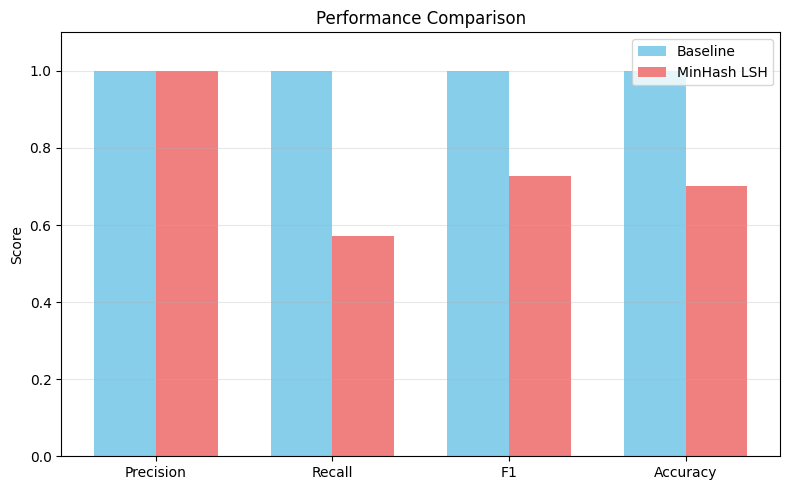

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
metrics = ['Precision', 'Recall', 'F1', 'Accuracy']
base_vals = [baseline['precision_mean'], baseline['recall_mean'], baseline['f1_mean'], baseline['accuracy_mean']]
mh_vals = [minhash['precision_mean'], minhash['recall_mean'], minhash['f1_mean'], minhash['accuracy_mean']]
x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, base_vals, width, label='Baseline', color='skyblue')
ax.bar(x + width/2, mh_vals, width, label='MinHash LSH', color='lightcoral')
ax.set_ylabel('Score')
ax.set_title('Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Example Predictions
Show some predictions.


In [18]:
np.random.seed(42)
test_pairs = generate_test_dataset(num_pairs=10)
base_d = BaselineNgramDetector(n=N_GRAM, threshold=BASELINE_THRESHOLD)
mh_d = MinHashDetector(num_hashes=NUM_HASHES, num_bands=NUM_BANDS, threshold=MINHASH_THRESHOLD)
for pair in test_pairs: mh_d.index_text(pair['text1'])
print('Pair ID | True | Baseline | MinHash')
for pair in test_pairs:
    bp = base_d.detect(pair['text1'], pair['text2'])
    similar = mh_d.detect(pair['text2'])
    mp = any(mh_d.doc_texts[cid] == pair['text1'] for cid in similar)
    print(f"{pair['pair_id']:<8} | {str(pair['is_duplicate']):<5} | {str(bp):<9} | {str(mp):<8}")


Pair ID | True | Baseline | MinHash
0        | False | False     | False   
1        | True  | True      | True    
2        | True  | True      | True    
3        | True  | True      | False   
4        | False | False     | False   
5        | True  | True      | False   
6        | True  | True      | True    
7        | True  | True      | True    
8        | True  | True      | False   
9        | True  | True      | True    
